# Stop Detection Results Exploration

This notebook explores the output of Step 1.1.1a (Infostop stop detection) to validate that the detected stops make sense.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import folium
from folium.plugins import MarkerCluster, HeatMap
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Stop Detection Results

In [2]:
# Load batch 0 results
stops_path = "/workspace/dbs/stops/stops_0.parquet"
df = pd.read_parquet(stops_path)

print(f"Loaded {len(df):,} stops")
print(f"Unique devices: {df['device_aid'].nunique():,}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 7,334,324 stops
Unique devices: 129,004

Columns: ['device_aid', 'interval', 'loc', 'start', 'end', 'latitude', 'longitude', 'size', 'localtime', 'l_localtime', 'batch', 'duration_min']


In [ ]:
# Preview data
df.head(10)

In [4]:
# Data types and info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7334324 entries, 0 to 7334323
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   device_aid    str    
 1   interval      int32  
 2   loc           int32  
 3   start         int32  
 4   end           int32  
 5   latitude      float64
 6   longitude     float64
 7   size          int64  
 8   localtime     int64  
 9   l_localtime   int64  
 10  batch         int64  
 11  duration_min  float64
dtypes: float64(3), int32(4), int64(4), str(1)
memory usage: 811.4 MB


In [5]:
# Basic statistics
df.describe()

,interval,loc,start,end,latitude,longitude,size,localtime,l_localtime,batch,duration_min
count,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7.334324e+06,7334324.0,7.334324e+06
mean,2.025657e+02,5.709763e+00,1.719895e+09,1.719915e+09,5.864531e+01,1.542731e+01,1.472895e+01,1.719899e+09,1.719919e+09,0.0,3.323585e+02
std,3.069951e+02,1.125897e+01,9.219913e+06,9.219897e+06,2.154433e+00,2.496371e+00,3.034808e+01,9.219913e+06,9.219897e+06,0.0,5.096117e+02
min,1.000000e+00,1.000000e+00,1.704067e+09,1.704068e+09,-2.740495e+01,-9.955840e+01,1.000000e+00,1.704071e+09,1.704072e+09,0.0,0.000000e+00
25%,3.200000e+01,1.000000e+00,1.711851e+09,1.711876e+09,5.718601e+01,1.303131e+01,3.000000e+00,1.711855e+09,1.711879e+09,0.0,5.833333e+01
50%,9.500000e+01,2.000000e+00,1.720081e+09,1.720095e+09,5.886073e+01,1.531998e+01,6.000000e+00,1.720085e+09,1.720098e+09,0.0,1.799833e+02
75%,2.390000e+02,5.000000e+00,1.727705e+09,1.727719e+09,5.942892e+01,1.784912e+01,1.600000e+01,1.727709e+09,1.727722e+09,0.0,4.256667e+02
max,6.690000e+03,5.710000e+02,1.735689e+09,1.735690e+09,6.896610e+01,1.351224e+02,1.382700e+04,1.735692e+09,1.735693e+09,0.0,9.517910e+04


## 2. Temporal Analysis

In [6]:
# Convert timestamps to datetime
df['start_dt'] = pd.to_datetime(df['start'], unit='s')
df['end_dt'] = pd.to_datetime(df['end'], unit='s')
df['local_start_dt'] = pd.to_datetime(df['localtime'], unit='s')
df['local_end_dt'] = pd.to_datetime(df['l_localtime'], unit='s')

# Extract time features
df['hour'] = df['local_start_dt'].dt.hour
df['day_of_week'] = df['local_start_dt'].dt.dayofweek
df['date'] = df['local_start_dt'].dt.date

print("Date range:")
print(f"  Start: {df['start_dt'].min()}")
print(f"  End: {df['end_dt'].max()}")

Date range:
  Start: 2024-01-01 00:00:00
  End: 2024-12-31 23:59:59


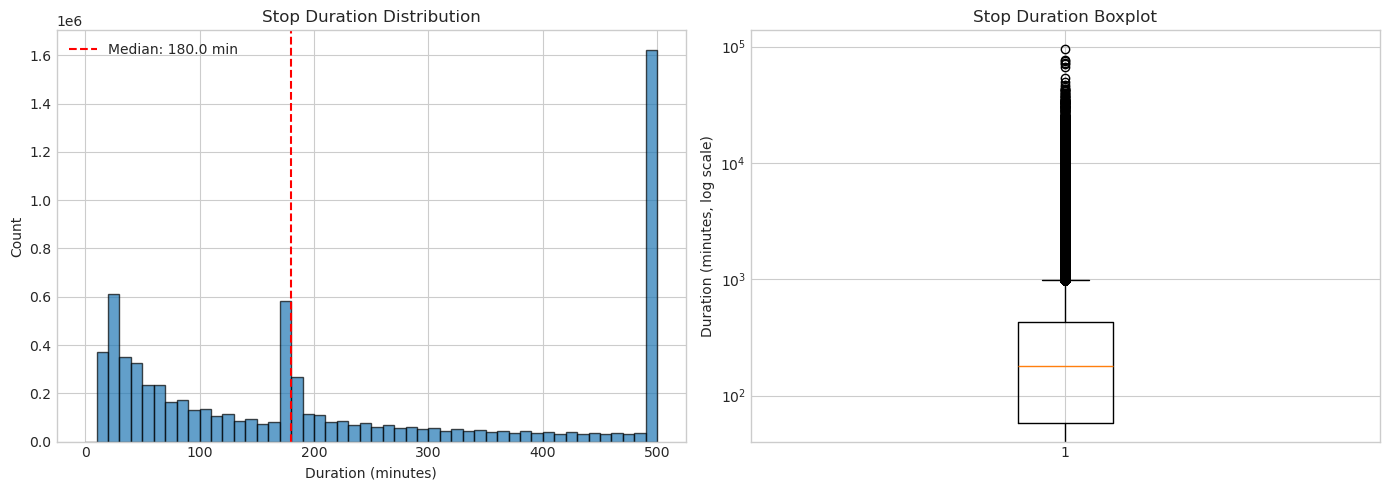


Duration Statistics (minutes):
  Min: 0.0
  25%: 58.3
  Median: 180.0
  75%: 425.7
  Max: 95179.1


In [7]:
# Stop duration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram (minutes)
ax1 = axes[0]
duration_mins = df['duration_min'].clip(upper=500)  # Clip for visualization
ax1.hist(duration_mins, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(df['duration_min'].median(), color='red', linestyle='--', label=f"Median: {df['duration_min'].median():.1f} min")
ax1.set_xlabel('Duration (minutes)')
ax1.set_ylabel('Count')
ax1.set_title('Stop Duration Distribution')
ax1.legend()

# Duration boxplot (log scale)
ax2 = axes[1]
ax2.boxplot(df['duration_min'], vert=True)
ax2.set_yscale('log')
ax2.set_ylabel('Duration (minutes, log scale)')
ax2.set_title('Stop Duration Boxplot')

plt.tight_layout()
plt.show()

print(f"\nDuration Statistics (minutes):")
print(f"  Min: {df['duration_min'].min():.1f}")
print(f"  25%: {df['duration_min'].quantile(0.25):.1f}")
print(f"  Median: {df['duration_min'].median():.1f}")
print(f"  75%: {df['duration_min'].quantile(0.75):.1f}")
print(f"  Max: {df['duration_min'].max():.1f}")

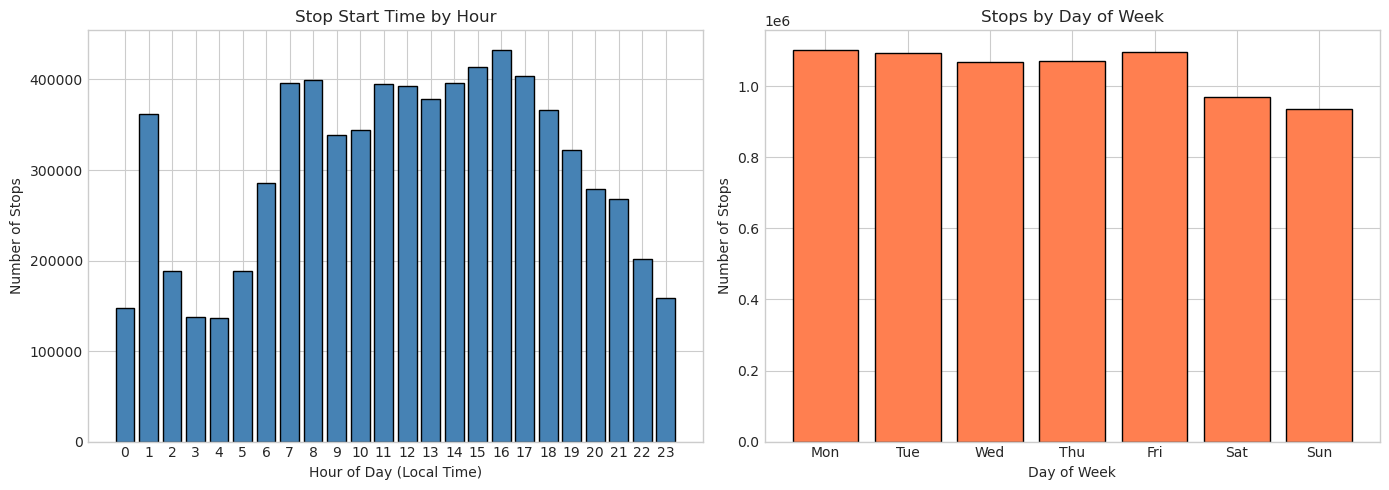

In [8]:
# Stops by hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by hour
ax1 = axes[0]
hour_counts = df['hour'].value_counts().sort_index()
ax1.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black')
ax1.set_xlabel('Hour of Day (Local Time)')
ax1.set_ylabel('Number of Stops')
ax1.set_title('Stop Start Time by Hour')
ax1.set_xticks(range(0, 24))

# Count by day of week
ax2 = axes[1]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().sort_index()
ax2.bar(day_counts.index, day_counts.values, color='coral', edgecolor='black')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Number of Stops')
ax2.set_title('Stops by Day of Week')
ax2.set_xticks(range(7))
ax2.set_xticklabels(day_names)

plt.tight_layout()
plt.show()

## 3. Spatial Analysis

In [9]:
# Geographic extent
print("Geographic Extent:")
print(f"  Latitude: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"  Longitude: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")

# Center point
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()
print(f"\nCenter: ({center_lat:.4f}, {center_lon:.4f})")

Geographic Extent:
  Latitude: -27.4049 to 68.9661
  Longitude: -99.5584 to 135.1224

Center: (58.6453, 15.4273)


In [ ]:
# Scatter plot of stop locations
fig, ax = plt.subplots(figsize=(10, 12))

# Sample for visualization (if too many points)
sample_size = min(50000, len(df))
sample = df.sample(n=sample_size, random_state=42)

scatter = ax.scatter(
    sample['longitude'], 
    sample['latitude'], 
    c=sample['duration_min'].clip(upper=120),
    cmap='YlOrRd',
    alpha=0.3,
    s=1
)
plt.colorbar(scatter, label='Duration (min, clipped at 120)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Stop Locations ({sample_size:,} sampled points)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [11]:
# Interactive map - sample of stops
# Take a smaller sample for the map
map_sample = df.sample(n=min(1000, len(df)), random_state=42)

# Create map centered on Sweden
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=5,
    tiles='CartoDB positron'
)

# Add heatmap layer
heat_data = [[row['latitude'], row['longitude']] for _, row in map_sample.iterrows()]
HeatMap(heat_data, radius=10).add_to(m)

m

## 4. Per-Device Analysis

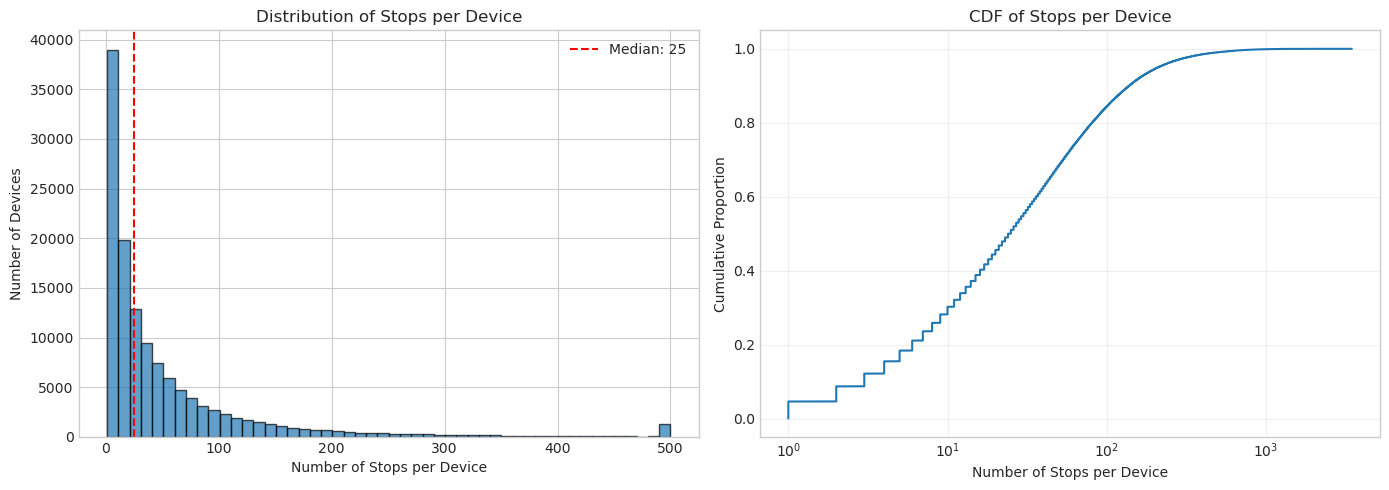

Stops per Device Statistics:
  Min: 1
  25%: 8
  Median: 25
  75%: 65
  Max: 3470


In [12]:
# Stops per device
stops_per_device = df.groupby('device_aid').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(stops_per_device.clip(upper=500), bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(stops_per_device.median(), color='red', linestyle='--', 
            label=f"Median: {stops_per_device.median():.0f}")
ax1.set_xlabel('Number of Stops per Device')
ax1.set_ylabel('Number of Devices')
ax1.set_title('Distribution of Stops per Device')
ax1.legend()

# CDF
ax2 = axes[1]
sorted_counts = np.sort(stops_per_device.values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax2.plot(sorted_counts, cdf)
ax2.set_xlabel('Number of Stops per Device')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('CDF of Stops per Device')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Stops per Device Statistics:")
print(f"  Min: {stops_per_device.min()}")
print(f"  25%: {stops_per_device.quantile(0.25):.0f}")
print(f"  Median: {stops_per_device.median():.0f}")
print(f"  75%: {stops_per_device.quantile(0.75):.0f}")
print(f"  Max: {stops_per_device.max()}")

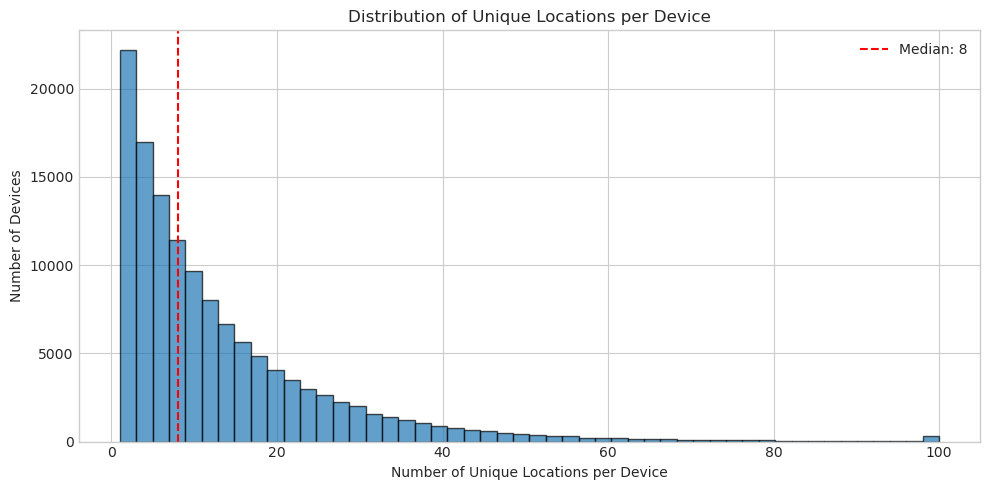

Unique Locations per Device:
  Median: 8
  Mean: 13.0


In [13]:
# Unique locations per device
unique_locs_per_device = df.groupby('device_aid')['loc'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(unique_locs_per_device.clip(upper=100), bins=50, edgecolor='black', alpha=0.7)
ax.axvline(unique_locs_per_device.median(), color='red', linestyle='--', 
           label=f"Median: {unique_locs_per_device.median():.0f}")
ax.set_xlabel('Number of Unique Locations per Device')
ax.set_ylabel('Number of Devices')
ax.set_title('Distribution of Unique Locations per Device')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Unique Locations per Device:")
print(f"  Median: {unique_locs_per_device.median():.0f}")
print(f"  Mean: {unique_locs_per_device.mean():.1f}")

## 5. Sample User Trajectory

In [14]:
# Select a user with a reasonable number of stops
good_users = stops_per_device[(stops_per_device >= 50) & (stops_per_device <= 200)]
sample_user = good_users.sample(1, random_state=42).index[0]

user_stops = df[df['device_aid'] == sample_user].sort_values('start').copy()
print(f"Sample user: {sample_user[:8]}...")
print(f"Number of stops: {len(user_stops)}")
print(f"Unique locations: {user_stops['loc'].nunique()}")
print(f"Date range: {user_stops['start_dt'].min().date()} to {user_stops['end_dt'].max().date()}")

Sample user: 2662d849...
Number of stops: 102
Unique locations: 29
Date range: 2024-05-06 to 2024-12-29


In [ ]:
# Map of sample user's stops
user_center_lat = user_stops['latitude'].mean()
user_center_lon = user_stops['longitude'].mean()

m = folium.Map(
    location=[user_center_lat, user_center_lon], 
    zoom_start=12,
    tiles='CartoDB positron'
)

# Color by location ID
colors = plt.cm.tab20(np.linspace(0, 1, user_stops['loc'].nunique()))
loc_colors = {loc: f'#{int(c[0]*255):02x}{int(c[1]*255):02x}{int(c[2]*255):02x}' 
              for loc, c in zip(user_stops['loc'].unique(), colors)}

# Add markers
for _, row in user_stops.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=loc_colors.get(row['loc'], 'gray'),
        fill=True,
        popup=f"Loc: {row['loc']}<br>Duration: {row['duration_min']:.0f} min<br>Time: {row['local_start_dt']}"
    ).add_to(m)

m

In [ ]:
# User's most visited locations
user_loc_counts = user_stops.groupby('loc').agg({
    'latitude': 'first',
    'longitude': 'first',
    'duration_min': ['count', 'sum', 'mean']
}).round(1)
user_loc_counts.columns = ['lat', 'lon', 'visit_count', 'total_duration_min', 'avg_duration_min']
user_loc_counts = user_loc_counts.sort_values('visit_count', ascending=False)

print("Top 10 Most Visited Locations:")
user_loc_counts.head(10)

In [ ]:
# User's stop pattern by hour
fig, ax = plt.subplots(figsize=(12, 5))

# Get top 3 locations
top_locs = user_loc_counts.head(3).index.tolist()

for loc in top_locs:
    loc_data = user_stops[user_stops['loc'] == loc]
    hour_counts = loc_data['hour'].value_counts().sort_index()
    ax.plot(hour_counts.index, hour_counts.values, marker='o', label=f'Location {loc}')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Stops')
ax.set_title(f'Stop Patterns by Hour for Top 3 Locations (User {sample_user[:8]}...)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Data Quality Checks

In [18]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
device_aid        0
interval          0
loc               0
start             0
end               0
latitude          0
longitude         0
size              0
localtime         0
l_localtime       0
batch             0
duration_min      0
start_dt          0
end_dt            0
local_start_dt    0
local_end_dt      0
hour              0
day_of_week       0
date              0
dtype: int64


In [19]:
# Check for invalid coordinates
invalid_lat = (df['latitude'] < 55) | (df['latitude'] > 70)  # Sweden lat range
invalid_lon = (df['longitude'] < 10) | (df['longitude'] > 25)  # Sweden lon range

print(f"Coordinates outside Sweden bounds:")
print(f"  Invalid latitude: {invalid_lat.sum():,} ({100*invalid_lat.mean():.2f}%)")
print(f"  Invalid longitude: {invalid_lon.sum():,} ({100*invalid_lon.mean():.2f}%)")

Coordinates outside Sweden bounds:
  Invalid latitude: 733 (0.01%)
  Invalid longitude: 483 (0.01%)


In [20]:
# Check duration outliers
very_short = df['duration_min'] < 15  # Less than minimum (shouldn't exist)
very_long = df['duration_min'] > 24*60  # More than 24 hours

print(f"Duration outliers:")
print(f"  Very short (<15 min): {very_short.sum():,} ({100*very_short.mean():.2f}%)")
print(f"  Very long (>24h): {very_long.sum():,} ({100*very_long.mean():.2f}%)")

Duration outliers:
  Very short (<15 min): 5 (0.00%)
  Very long (>24h): 163,617 (2.23%)


In [21]:
# Check if local time conversion looks correct
# In Sweden, most activity should be during day hours (6-22)
day_hours = (df['hour'] >= 6) & (df['hour'] <= 22)
print(f"Stops during day hours (6-22): {day_hours.sum():,} ({100*day_hours.mean():.1f}%)")
print(f"Stops during night hours (23-5): {(~day_hours).sum():,} ({100*(~day_hours).mean():.1f}%)")

Stops during day hours (6-22): 6,015,525 (82.0%)
Stops during night hours (23-5): 1,318,799 (18.0%)


## 7. Summary Statistics for HoWDe Input

In [22]:
# Verify the data is ready for HoWDe
print("HoWDe Input Verification:")
print("="*50)

# Check required columns exist
required_cols = ['device_aid', 'loc', 'localtime', 'l_localtime']
for col in required_cols:
    exists = col in df.columns
    print(f"  {col}: {'OK' if exists else 'MISSING'}")

print("\nColumn Mapping for HoWDe:")
print("  device_aid -> useruuid")
print("  loc -> loc (location ID)")
print("  localtime -> start (local time)")
print("  l_localtime -> end (local time)")

print(f"\nData Summary:")
print(f"  Total stops: {len(df):,}")
print(f"  Unique devices: {df['device_aid'].nunique():,}")
print(f"  Unique locations: {df['loc'].nunique():,}")
print(f"  Date range: {df['start_dt'].min().date()} to {df['end_dt'].max().date()}")

HoWDe Input Verification:
  device_aid: OK
  loc: OK
  localtime: OK
  l_localtime: OK

Column Mapping for HoWDe:
  device_aid -> useruuid
  loc -> loc (location ID)
  localtime -> start (local time)
  l_localtime -> end (local time)

Data Summary:
  Total stops: 7,334,324
  Unique devices: 129,004
  Unique locations: 571
  Date range: 2024-01-01 to 2024-12-31


In [23]:
# Save summary stats
summary = {
    'batch': 0,
    'total_stops': len(df),
    'unique_devices': df['device_aid'].nunique(),
    'unique_locations': df['loc'].nunique(),
    'median_stops_per_device': stops_per_device.median(),
    'median_duration_min': df['duration_min'].median(),
    'date_start': str(df['start_dt'].min().date()),
    'date_end': str(df['end_dt'].max().date()),
}

print("\nBatch 0 Summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")


Batch 0 Summary:
  batch: 0
  total_stops: 7334324
  unique_devices: 129004
  unique_locations: 571
  median_stops_per_device: 25.0
  median_duration_min: 179.98333333333332
  date_start: 2024-01-01
  date_end: 2024-12-31
